# query: Posterior Query Tool

Computes the probability, per data point, that posterior realizations satisfy
a user-defined feature constraint.

The core function `query(f_post_h5, query)` takes a posterior HDF5
file and a query definition (dict or JSON file path) and returns an array of

probabilities – one value per data location.

In [1]:
try:
    get_ipython()
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

In [2]:
import json

import h5py
import numpy as np
import matplotlib.pyplot as plt
import integrate as ig

## Query structure

A query is a dict (or JSON file) with a `"constraints"` list.
Constraints are evaluated sequentially (implicit AND): a realization must
pass **all** constraints to be counted.

### Discrete-model constraint  (e.g. lithology class, im=2)
```json
{
  "im": 2,
  "classes": [1, 2],
  "thickness_mode": "cumulative",
  "thickness_comparison": ">",
  "thickness_threshold": 10.0,
  "depth_min": 0.0,
  "depth_max": 30.0,
  "negate": false
}
```

### Continuous-model constraint  (e.g. resistivity, im=1)
```json
{
  "im": 1,
  "value_comparison": "<",
  "value_threshold": 500.0,
  "thickness_mode": "cumulative",
  "thickness_comparison": ">",
  "thickness_threshold": 0.0,
  "depth_min": 0.0,
  "depth_max": 100.0,
  "negate": false
}
```

**All fields:**

| Field | Type | Description |
|---|---|---|
| `im` | int | Prior model index (1-based) |
| `classes` | list[int] | Class IDs to match (discrete only) |
| `value_comparison` | str | `"<"` or `">"` (continuous only) |
| `value_threshold` | float | Value threshold for continuous condition |
| `thickness_mode` | str | `"cumulative"` or `"first_occurrence"` |
| `thickness_comparison` | str | `">"`, `"<"`, `">="`, `"<="` |
| `thickness_threshold` | float | Thickness [m] to compare against |
| `depth_min` | float | Optional lower depth bound [m] |
| `depth_max` | float | Optional upper depth bound [m] |
| `negate` | bool | If True, accept realizations that do NOT satisfy the constraint |

---
## Core Functions

The core query functions (query, query_plot, save_query, load_query, get_prior_model_info)
are available from the integrate module.
Access them as:
- ig.query()
- ig.query_plot()
- ig.save_query()
- ig.load_query()
- ig.get_prior_model_info()

All helper functions and implementation details are in integrate/integrate_query.py

---
## Examples

The examples below use the posterior and prior files from the `examples/`
directory. They are guarded with `os.path.isfile` so the script can be
imported without errors if the files are absent.
import integrate as ig
f_post_h5 = 'post_daugaard_merged_N2000000_Nuse1000000_inflateNoise2.h5'
with h5py.File(f_post_h5, 'r') as f:
    f_prior_h5 = str(f.attrs.get('f5_prior', ''))
    f_data_h5 = str(f.attrs.get('f5_data', ''))
X, Y, LINE, ELEVATION = ig.get_geometry(f_data_h5)

z = []
dz = []
with h5py.File(f_prior_h5, 'r') as f:
    for k in f.keys():
        if k.startswith('M'):
            z.append(f[k].attrs['x'].astype(float))
            # dz = [diff(z),0]
            dz.append(np.append(np.diff(z[-1]), 0))

ig.plot_profile(f_post_h5, i1 = 0, i2=600, im=2)
M, idx = ig.load_prior_model(f_prior_h5)

In [3]:
# Select posterior hdf5 file to query 
# (here an example the outcome og integrate_workflow.py)
f_post_h5= 'post_DAUGAARD_AVG_WF_id1_2_3_4_5_6_7_8_9_10_11_12_13.h5'
# Select data location to plot 
ip = 1000

### Example 1: Discrete constraint

Probability that the cumulative thickness of lithology class 2
within 0–30 m depth is greater than 10 m.

Query saved to query_ex0.json


Evaluating query: 100%|██████████████████████████████████████████████████████████████████████| 11693/11693 [00:01<00:00, 6649.48location/s]


Example 0 | N_data=11693, mean P=0.277


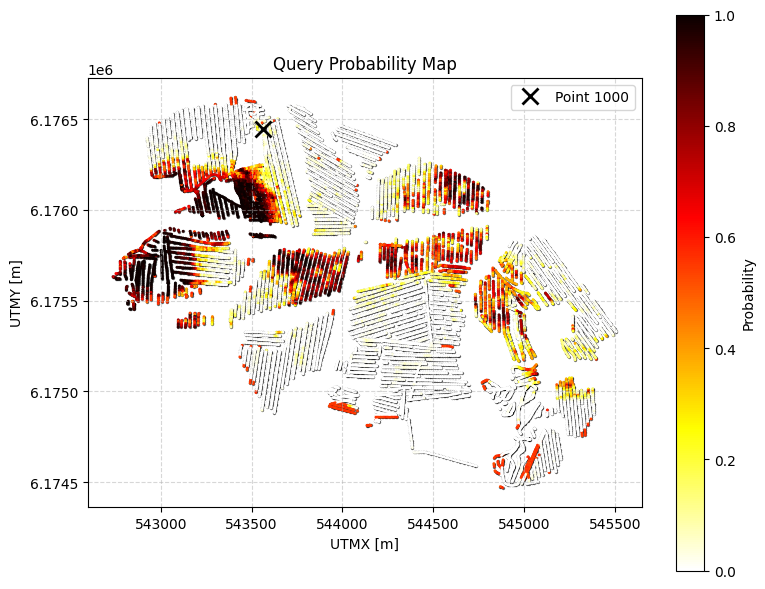

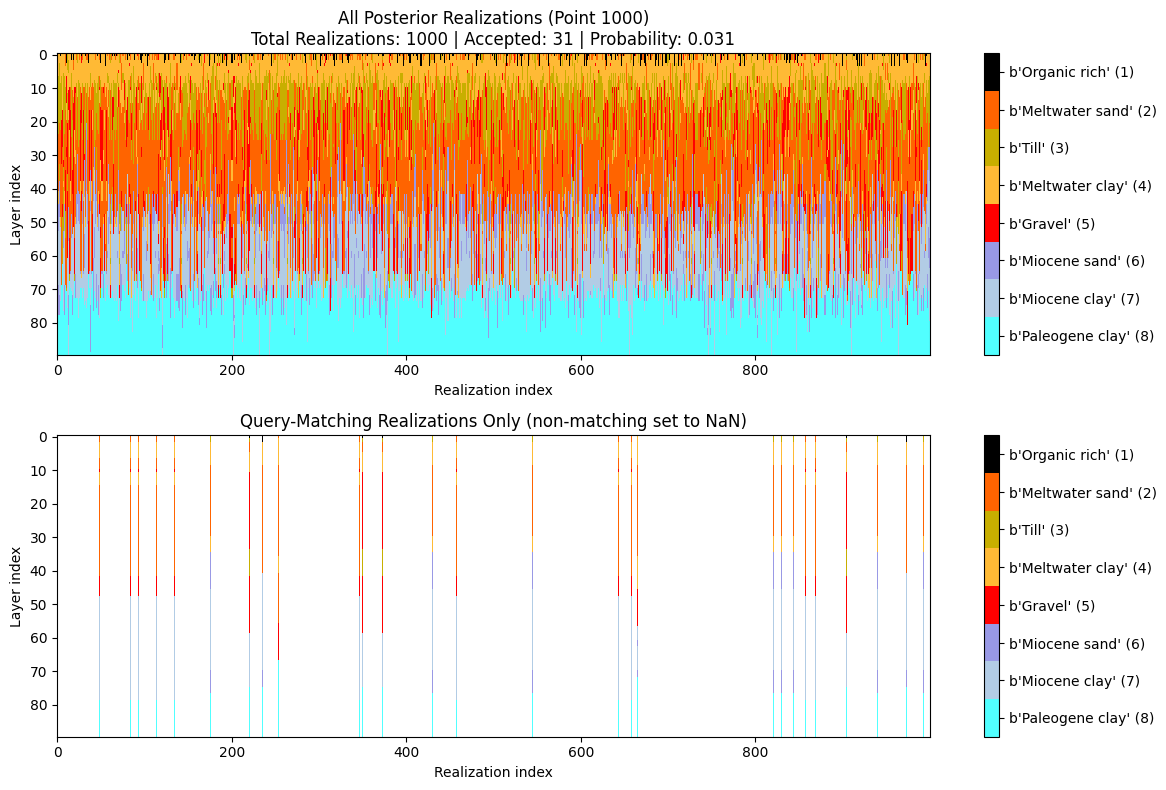

In [4]:
# Q0: FIND THE TOTAL AMOUNT OF SAND and GRAVEL above 30 m depth!
query_ex0 = {
    "constraints": [
        {
            "im": 2,
            "classes": [2,5],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 20.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex0, 'query_ex0.json')

P0, meta0 = ig.query(f_post_h5, query_ex0)
print(f"Example 0 | N_data={meta0['N_data']}, mean P={P0.mean():.3f}")

# Simple: just probability map
# ig.query_plot(P0, meta0)

# Detailed: probability map + model visualization for point 1000
ig.query_plot(P0, meta0, ip=ip, query_dict=query_ex0, f_post_h5=f_post_h5)

In [5]:
# Pause execution here to allow inspection of the plots before the script continues
#input("Press Enter to continue with manual computation...")

### Example 0b: Q0 with additional constraint on top layer thickness

Same as Q0 (sand and gravel cumulative thickness > 20m within 0-30m)
BUT with an additional constraint: any top layer that is NOT sand/gravel
cannot be thicker than 3m.

Query saved to query_ex0b.json


Evaluating query: 100%|███████████████████████████████████████████████████████████████████████| 11693/11693 [00:46<00:00, 252.84location/s]


Example 0b | N_data=11693, mean P=0.101


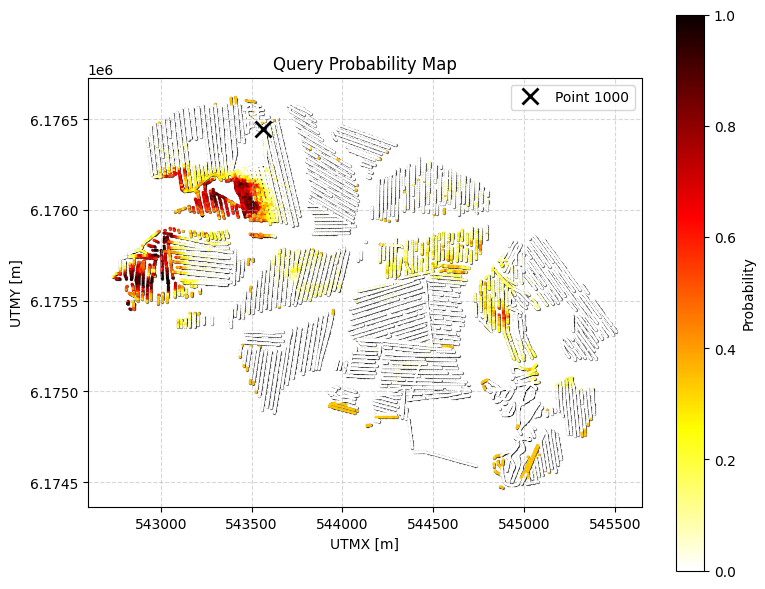

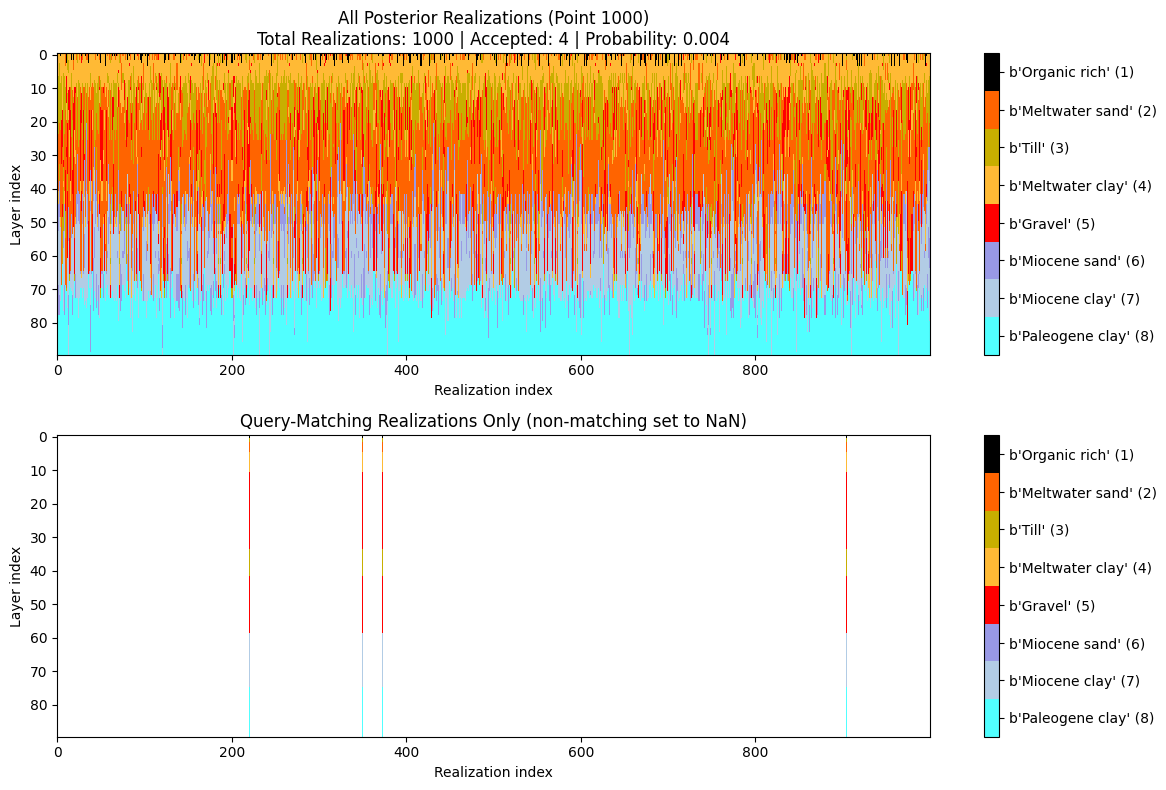

In [6]:
query_ex0b = {
    "constraints": [
        {
            "im": 2,
            "classes": [2, 5],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 20.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        },
        {
            "im": 2,
            "classes": [1, 3, 4, 6, 7, 8],  # All classes except sand (2) and gravel (5)
            "thickness_mode": "first_occurrence",
            "thickness_comparison": "<",
            "thickness_threshold": 3.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex0b, 'query_ex0b.json')

P0b, meta0b = ig.query(f_post_h5, query_ex0b)
print(f"Example 0b | N_data={meta0b['N_data']}, mean P={P0b.mean():.3f}")

# Detailed visualization for a specific point
ig.query_plot(P0b, meta0b, ip=ip, query_dict=query_ex0b, f_post_h5=f_post_h5)

### Example 0c: Q0 with minimum overburden thickness constraint

Same as Q0 (sand and gravel cumulative thickness > 20m within 0-30m)
BUT with an additional constraint: there must be AT LEAST 2m of overburden
(non-sand/gravel material) within 0-30m depth.

Overburden = all classes except sand (2) and gravel (5)

Query saved to query_ex0c.json


Evaluating query: 100%|██████████████████████████████████████████████████████████████████████| 11693/11693 [00:03<00:00, 3589.94location/s]


Example 0c | N_data=11693, mean P=0.202


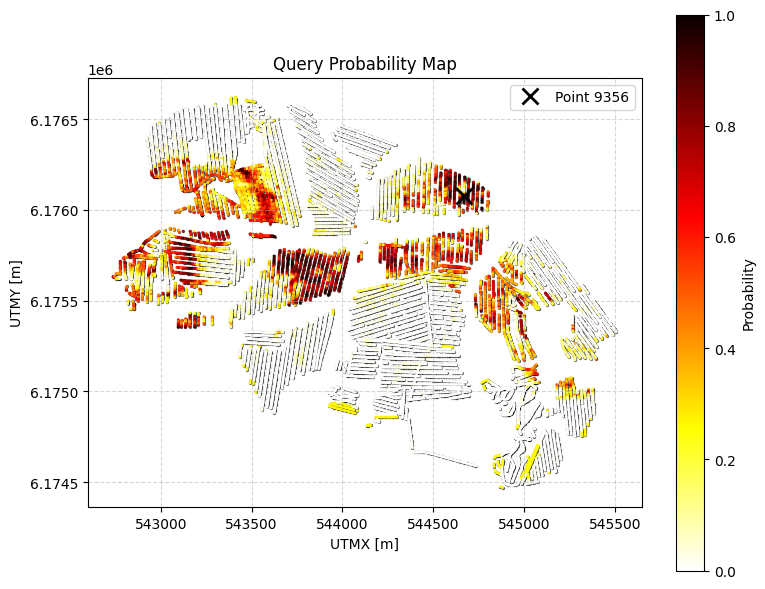

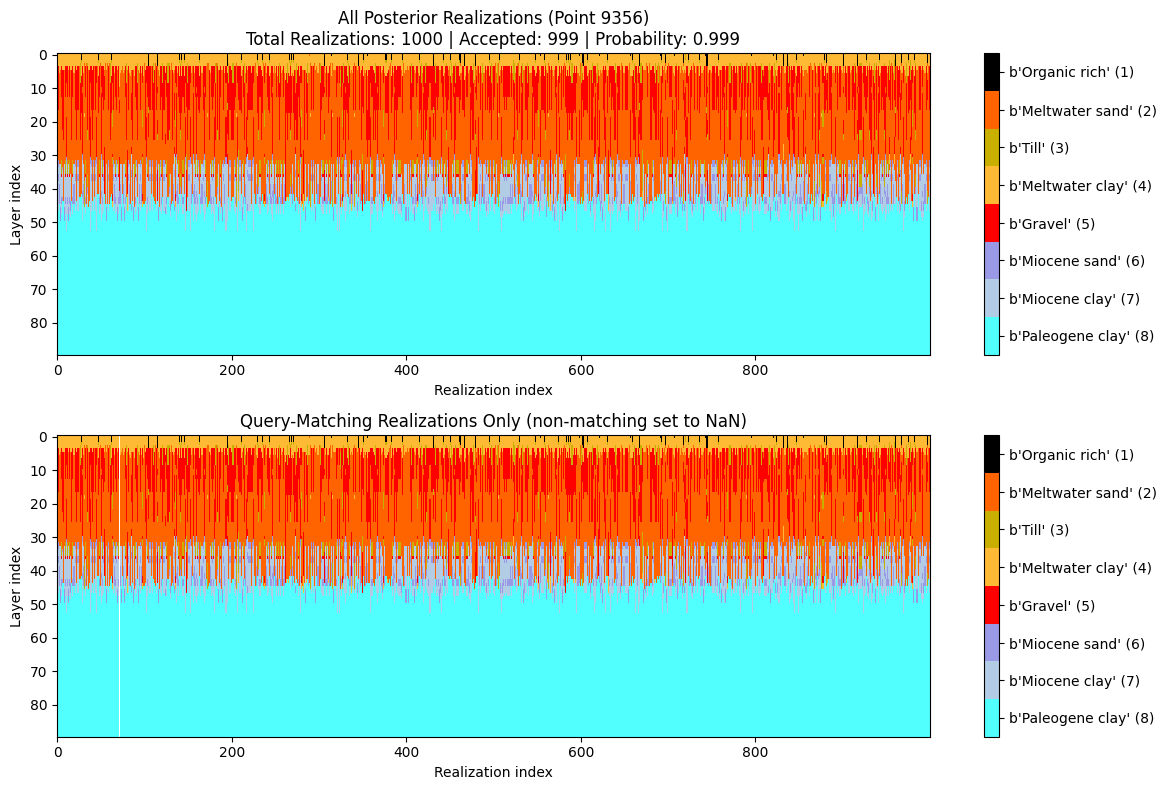

In [7]:
query_ex0c = {
    "constraints": [
        {
            "im": 2,
            "classes": [2, 5],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 20.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        },
        {
            "im": 2,
            "classes": [1, 3, 4, 6, 7, 8],  # Overburden: all classes except sand (2) and gravel (5)
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 2.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex0c, 'query_ex0c.json')

P0c, meta0c = ig.query(f_post_h5, query_ex0c)
print(f"Example 0c | N_data={meta0c['N_data']}, mean P={P0c.mean():.3f}")

# 
# choose ip_example is the index of the point with laregs P0c
ip_example = np.argmax(P0c)

# Detailed visualization for a specific point
ig.query_plot(P0c, meta0c, ip=ip_example, query_dict=query_ex0c, f_post_h5=f_post_h5)

### Example 0d: Q0 with NO overburden constraint

Same as Q0 (sand and gravel cumulative thickness > 20m within 0-30m)
BUT with an additional constraint: there can be NO overburden at the top.
This means either sand (class 2) or gravel (class 5) must be the top layer.

Overburden = all classes except sand (2) and gravel (5)

Query saved to query_ex0d.json


Evaluating query: 100%|███████████████████████████████████████████████████████████████████████| 11693/11693 [00:46<00:00, 253.30location/s]


Example 0d | N_data=11693, mean P=0.043


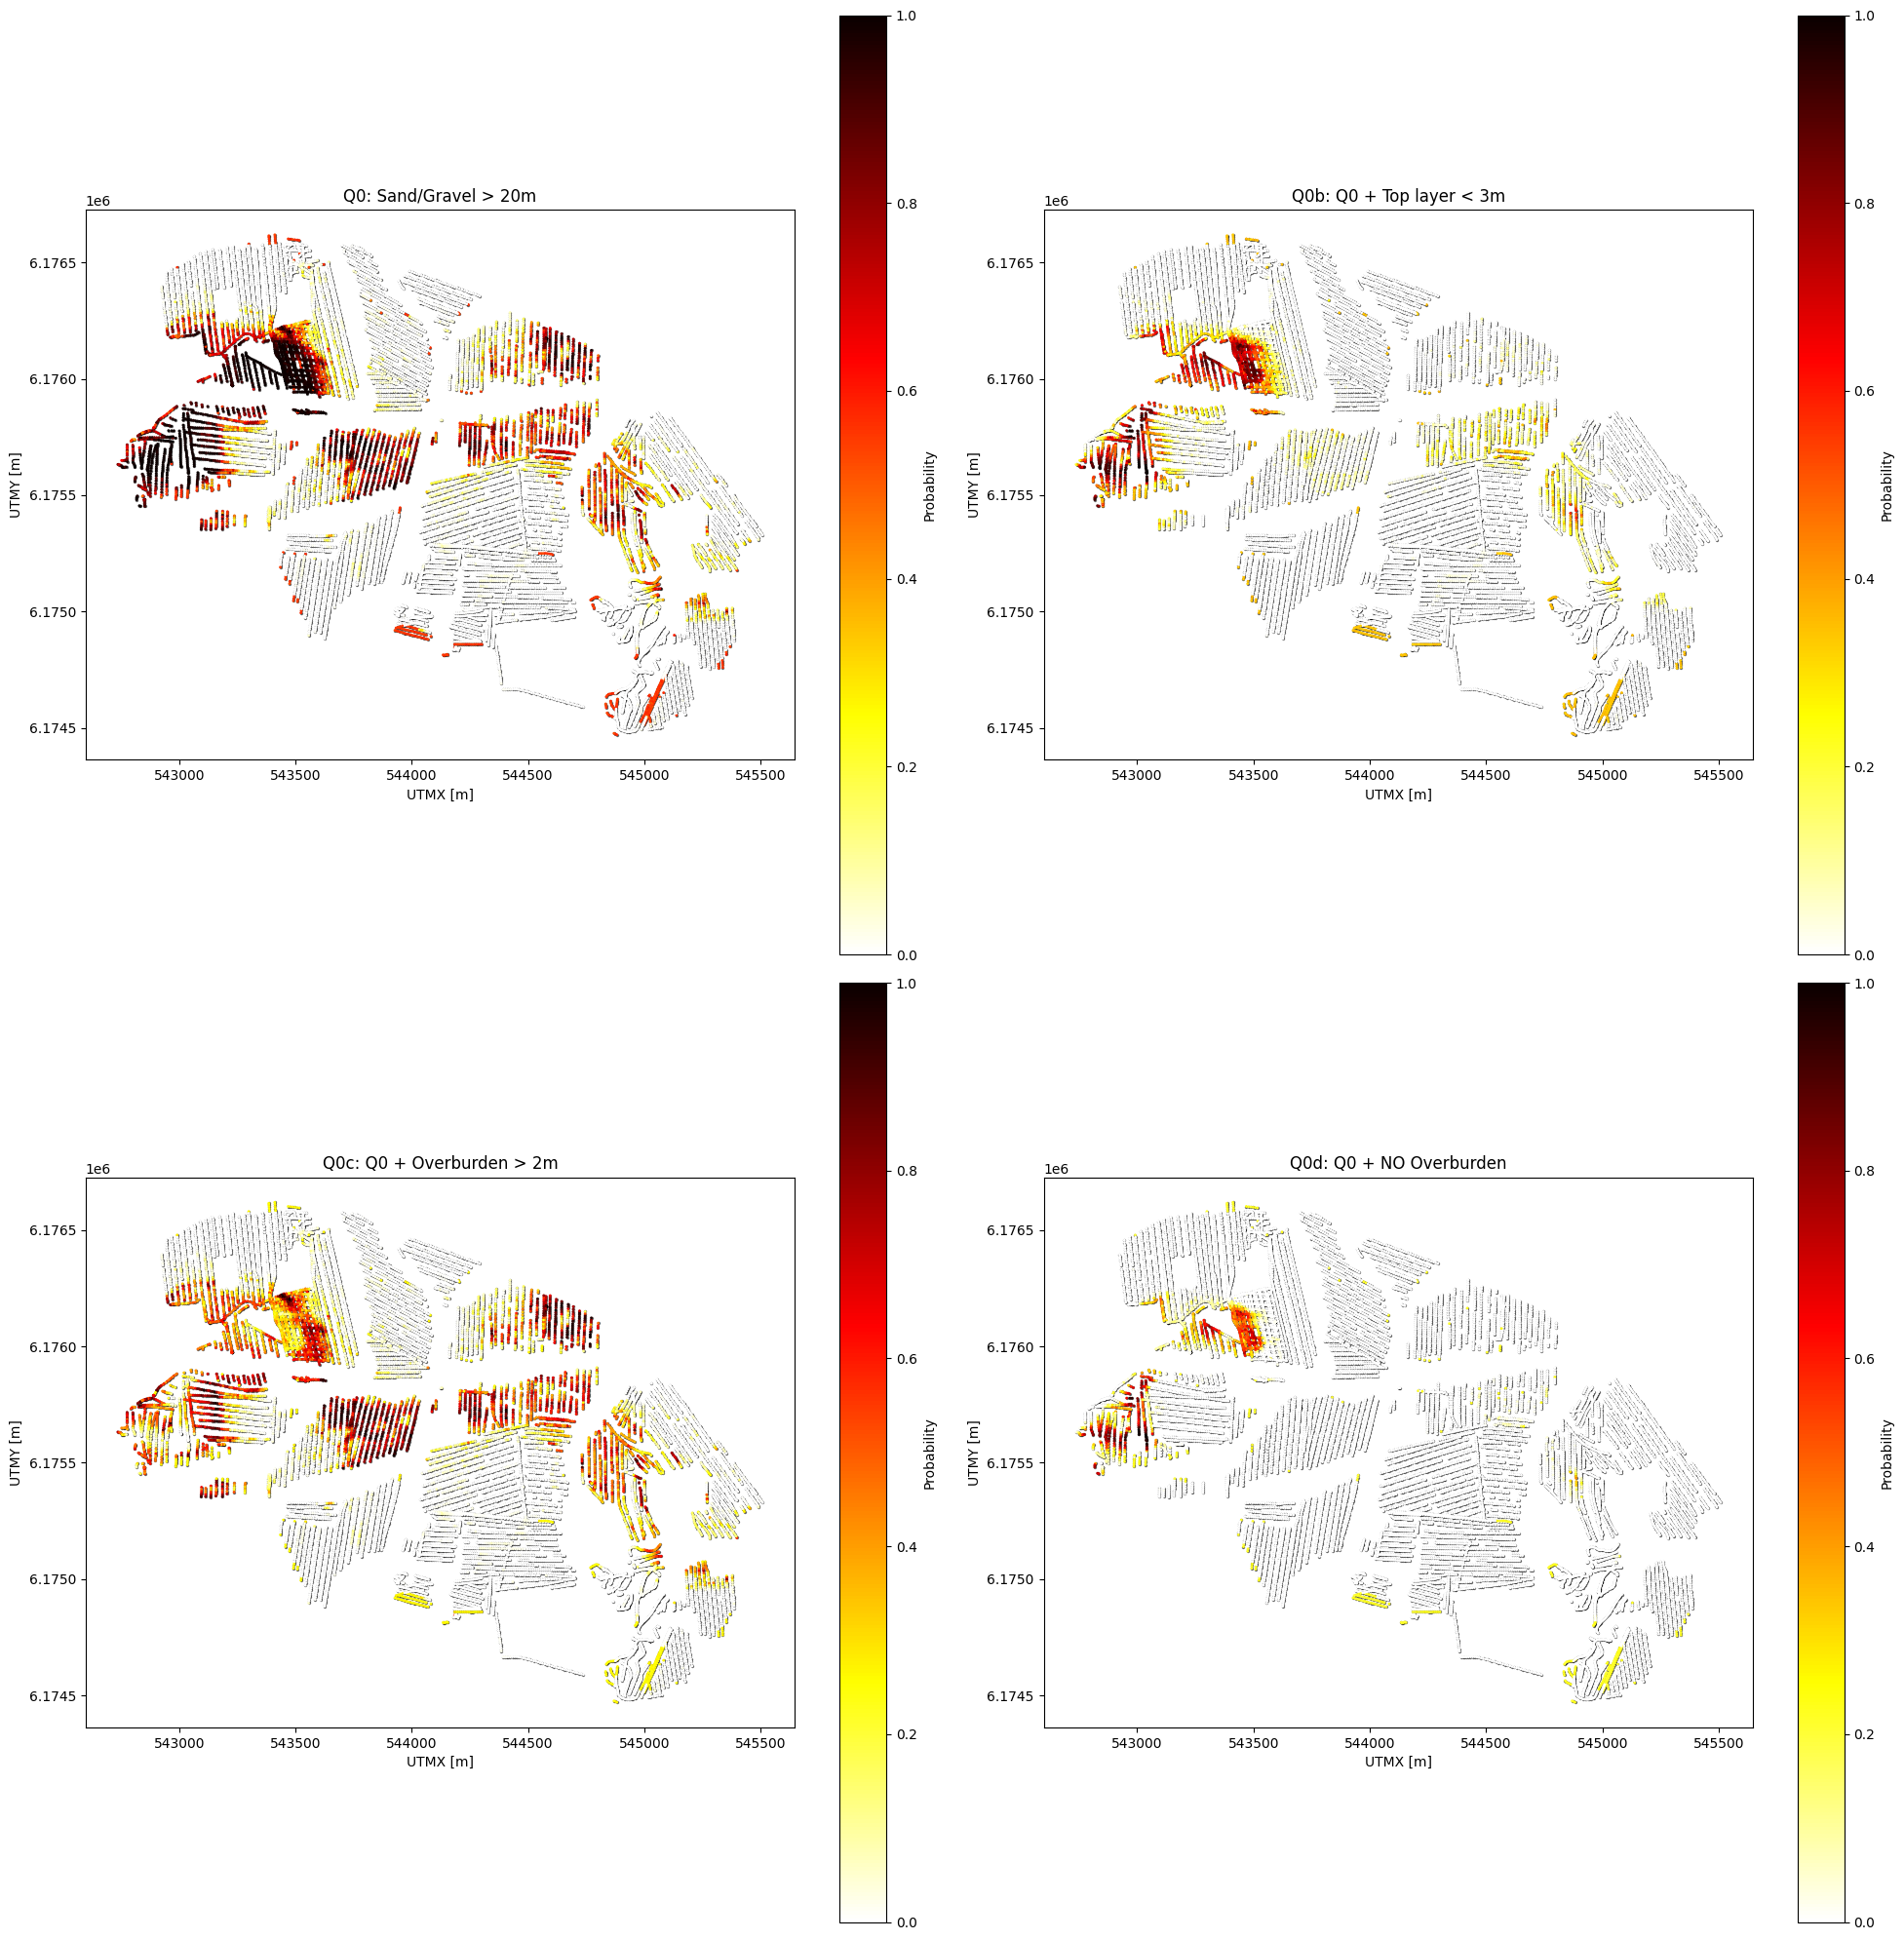

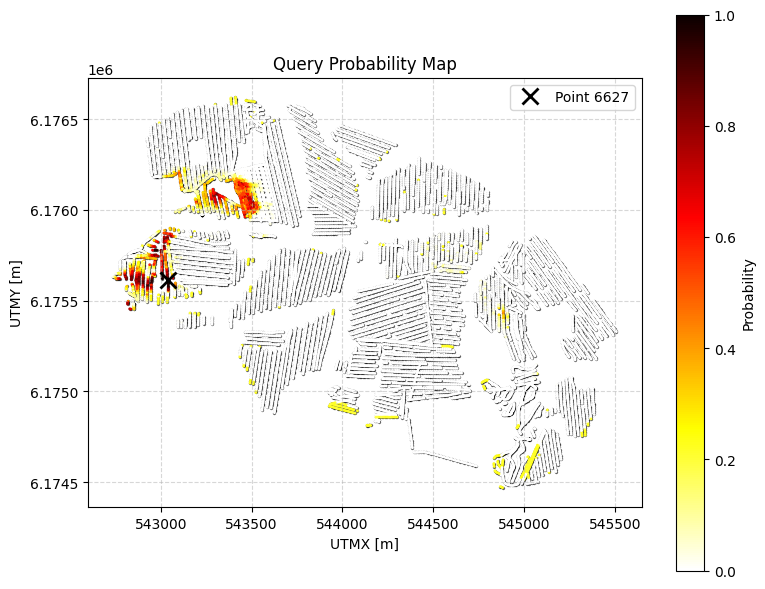

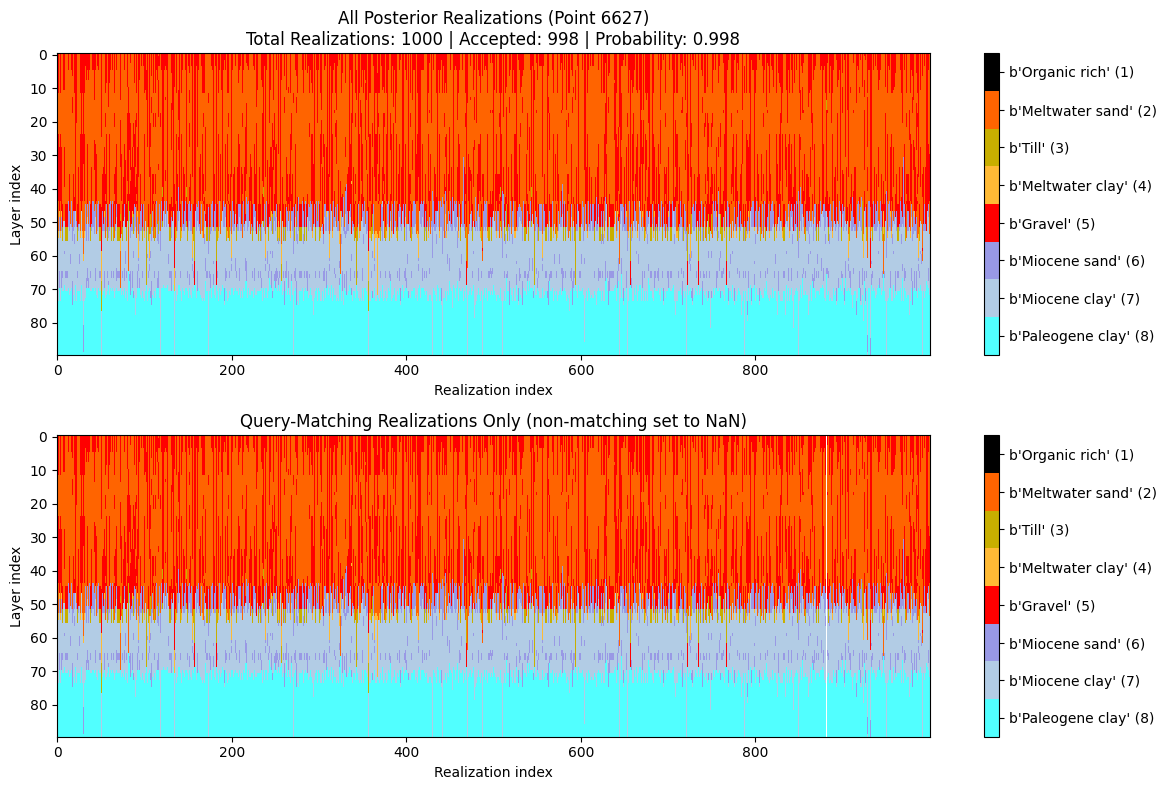

In [8]:
query_ex0d = {
    "constraints": [
        {
            "im": 2,
            "classes": [2, 5],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 20.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        },
        {
            "im": 2,
            "classes": [1, 3, 4, 6, 7, 8],  # Overburden: all classes except sand (2) and gravel (5)
            "thickness_mode": "first_occurrence",
            "thickness_comparison": "<",
            "thickness_threshold": 0.1,  # Essentially 0 (with small numerical tolerance)
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex0d, 'query_ex0d.json')

P0d, meta0d = ig.query(f_post_h5, query_ex0d)
print(f"Example 0d | N_data={meta0d['N_data']}, mean P={P0d.mean():.3f}")

# Plot comparison: Q0, Q0b, Q0c, and Q0d
plt.figure(figsize=(20, 20))

plt.subplot(2, 2, 1)
ax1 = plt.gca()
ax1.scatter(meta0['X'], meta0['Y'], c='black', s=2, alpha=0.5)
sc1 = ax1.scatter(meta0['X'], meta0['Y'], c=P0, cmap='hot_r', vmin=0, vmax=1, s=1)
plt.colorbar(sc1, label='Probability')
plt.xlabel('UTMX [m]')
plt.ylabel('UTMY [m]')
plt.title('Q0: Sand/Gravel > 20m')
plt.gca().set_aspect('equal')

plt.subplot(2, 2, 2)
ax2 = plt.gca()
ax2.scatter(meta0b['X'], meta0b['Y'], c='black', s=2, alpha=0.5)
sc2 = ax2.scatter(meta0b['X'], meta0b['Y'], c=P0b, cmap='hot_r', vmin=0, vmax=1, s=1)
plt.colorbar(sc2, label='Probability')
plt.xlabel('UTMX [m]')
plt.ylabel('UTMY [m]')
plt.title('Q0b: Q0 + Top layer < 3m')
plt.gca().set_aspect('equal')

plt.subplot(2, 2, 3)
ax3 = plt.gca()
ax3.scatter(meta0c['X'], meta0c['Y'], c='black', s=2, alpha=0.5)
sc3 = ax3.scatter(meta0c['X'], meta0c['Y'], c=P0c, cmap='hot_r', vmin=0, vmax=1, s=1)
plt.colorbar(sc3, label='Probability')
plt.xlabel('UTMX [m]')
plt.ylabel('UTMY [m]')
plt.title('Q0c: Q0 + Overburden > 2m')
plt.gca().set_aspect('equal')

plt.subplot(2, 2, 4)
ax4 = plt.gca()
ax4.scatter(meta0d['X'], meta0d['Y'], c='black', s=2, alpha=0.5)
sc4 = ax4.scatter(meta0d['X'], meta0d['Y'], c=P0d, cmap='hot_r', vmin=0, vmax=1, s=1)
plt.colorbar(sc4, label='Probability')
plt.xlabel('UTMX [m]')
plt.ylabel('UTMY [m]')
plt.title('Q0d: Q0 + NO Overburden')
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.savefig('query_example0d_comparison.png', dpi=150)
plt.show()

# Choose ip_example as the index of the point with largest P0d
ip_example = np.argmax(P0d)

# Detailed visualization for a specific point
ig.query_plot(P0d, meta0d, ip=ip_example, query_dict=query_ex0d, f_post_h5=f_post_h5)

Query saved to query_ex1.json


Evaluating query: 100%|██████████████████████████████████████████████████████████████████████| 11693/11693 [00:03<00:00, 3534.67location/s]


Example 1 | N_data=11693, mean P=0.248


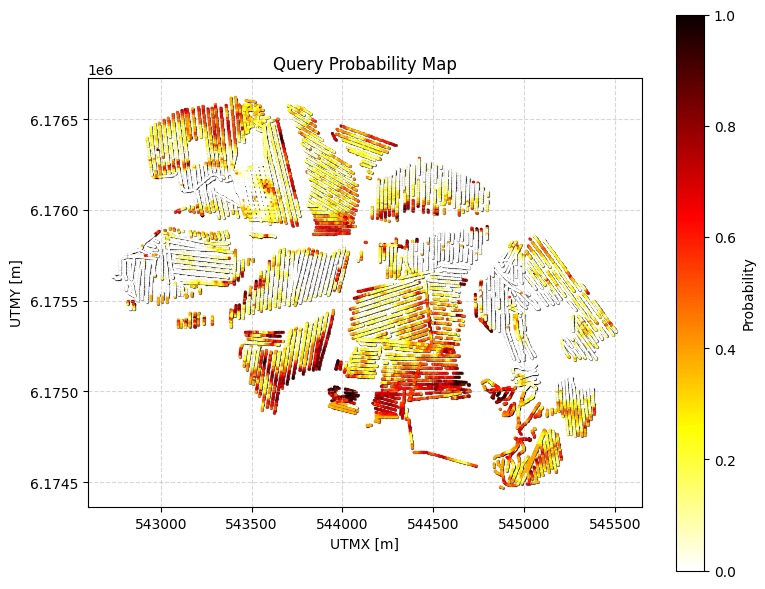

In [9]:
query_ex1 = {
    "constraints": [
        {
            "im": 2,
            "classes": [7],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 23.0,
            "depth_min": 0.0,
            "depth_max": 100.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex1, 'query_ex1.json')

P1, meta1 = ig.query(f_post_h5, query_ex1)
print(f"Example 1 | N_data={meta1['N_data']}, mean P={P1.mean():.3f}")

ig.query_plot(P1, meta1)

### Example 2: Continuous constraint

Probability that resistivity (im=1) is less than 100 ohm-m
for a cumulative thickness of at least 5 m within 0–50 m depth.

Query saved to query_ex2.json


Evaluating query: 100%|█████████████████████████████████████████████████████████████████████| 11693/11693 [00:00<00:00, 11946.59location/s]


Example 2 | N_data=11693, mean P=0.641


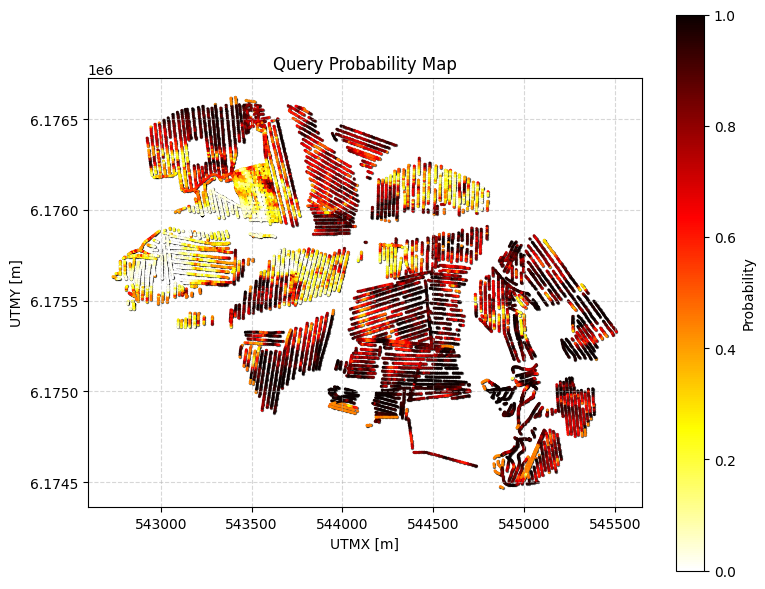

In [10]:
query_ex2 = {
    "constraints": [
        {
            "im": 1,
            "value_comparison": "<",
            "value_threshold": 100.0,
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 25.0,
            "depth_min": 0.0,
            "depth_max": 50.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex2, 'query_ex2.json')

P2, meta2 = ig.query(f_post_h5, query_ex2)
print(f"Example 2 | N_data={meta2['N_data']}, mean P={P2.mean():.3f}")

ig.query_plot(P2, meta2)

### Example 3: Combined constraint (AND)

Probability that:
1. Clay (class 2) cumulative thickness > 5 m within 0–20 m, AND
2. Resistivity > 500 ohm-m for at least 1 m within 20–60 m (negated: no
   such layer → probability of the opposite).

Query saved to query_ex3.json


Evaluating query: 100%|██████████████████████████████████████████████████████████████████████| 11693/11693 [00:02<00:00, 5338.49location/s]


Example 3 | N_data=11693, mean P=0.000


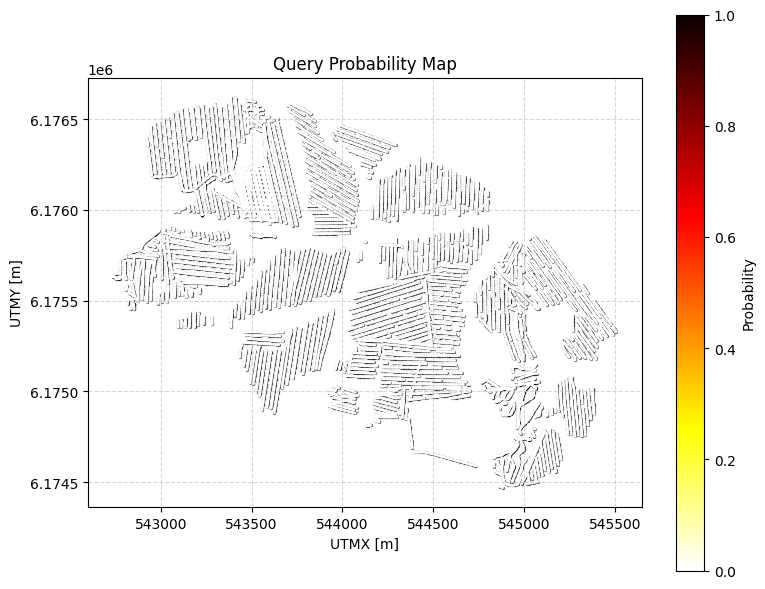

In [11]:
query_ex3 = {
    "constraints": [
        {
            "im": 2,
            "classes": [2],
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 5.0,
            "depth_min": 0.0,
            "depth_max": 20.0,
            "negate": False
        },
        {
            "im": 1,
            "value_comparison": ">",
            "value_threshold": 500.0,
            "thickness_mode": "cumulative",
            "thickness_comparison": ">",
            "thickness_threshold": 1.0,
            "depth_min": 20.0,
            "depth_max": 60.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex3, 'query_ex3.json')

P3, meta3 = ig.query(f_post_h5, query_ex3)
print(f"Example 3 | N_data={meta3['N_data']}, mean P={P3.mean():.3f}")

ig.query_plot(P3, meta3)

### Example 4: First-occurrence thickness

Probability that the first contiguous occurrence of clay (class 2)
is less than 5 m thick within 0–30 m depth.

Query saved to query_ex4.json


Evaluating query: 100%|███████████████████████████████████████████████████████████████████████| 11693/11693 [00:24<00:00, 484.97location/s]


Example 4 | N_data=11693, mean P=0.509


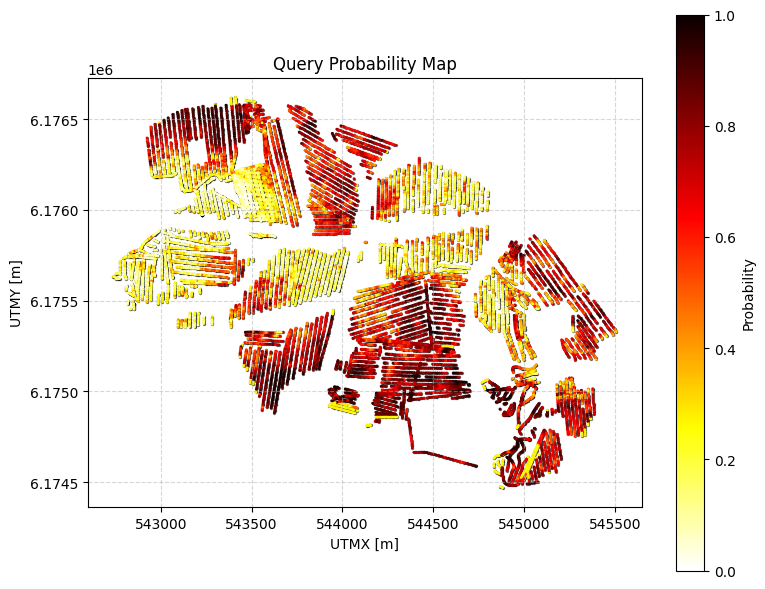

In [12]:
query_ex4 = {
    "constraints": [
        {
            "im": 2,
            "classes": [2],
            "thickness_mode": "first_occurrence",
            "thickness_comparison": "<",
            "thickness_threshold": 5.0,
            "depth_min": 0.0,
            "depth_max": 30.0,
            "negate": False
        }
    ]
}

ig.save_query(query_ex4, 'query_ex4.json')

P4, meta4 = ig.query(f_post_h5, query_ex4)
print(f"Example 4 | N_data={meta4['N_data']}, mean P={P4.mean():.3f}")

ig.query_plot(P4, meta4)

### Example 5: Load a saved query from JSON and plot results

Evaluating query: 100%|██████████████████████████████████████████████████████████████████████| 11693/11693 [00:03<00:00, 3526.02location/s]


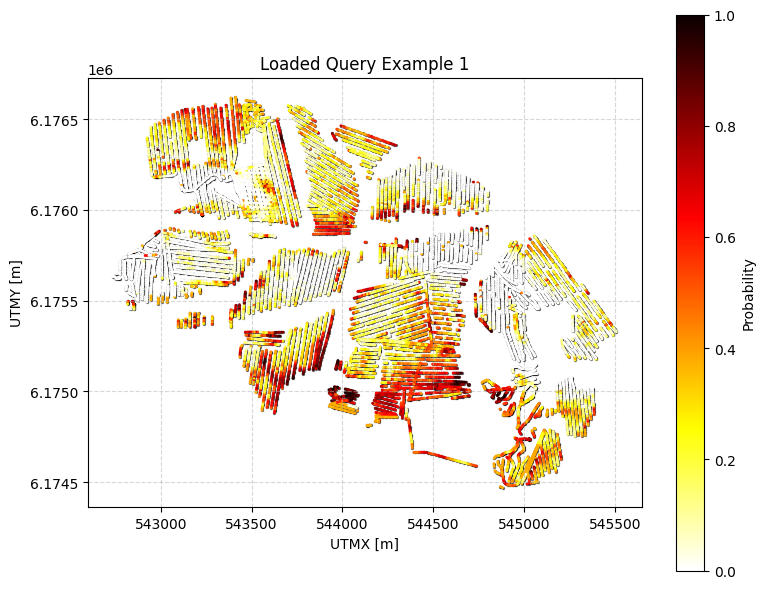

In [13]:
q = ig.load_query('query_ex1.json')
P, meta = ig.query(f_post_h5, q)
ig.query_plot(P, meta, title='Loaded Query Example 1')